# Arbeid

## Doelen

Nu dat we de microscopische grootheden van de moleculen hebben verbonden aan de macroscopische grootheden van het gas, kunnen we de thermodynamica van het gas echt modelleren met onze simulatie. In dit werkblad gaan we kijken hoe de temperatuur en de druk veranderen onder invloed van een zuiger die het volume verandert. 

Eerst herhalen we de delen van de code die we nodig hebben:

- klasse voor het deeltje met bijbehorende functies
- variabelen en randcondities van controle volume
- functies voor een lijst deeltjes

Daarna voegen we code toe voor de dynamiek van de zuiger:

- zuiger implementeren in volume en dynamische formules
- bestuderen van temperatuur en druk als functie van volume
- onderzoeken of we terug kunnen keren naar startcondities

## Laden van eerdere code

We beginnen weer met de noodzakelijke pakketten en de constanten. Daar voegen we nu een constante aan toe: de startsnelheid van de zuiger. 

```{exercise}
Neem de constanten die je in het vorige werkblad hebt gekozen hieronder over.
```

(Tekst Freek: 10 deeltjes, met bewegend wand, eerst isotherm (snelheid van deeltjes niet gewijzigd) - snelheid van deeltjes verandert wel door beweging vd wand. p(t) en p(V))

In [1]:
# ruimte voor uitwerking

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

BOX_SIZE_0 = 0               # Hoogte en lengte startvolume
N = 40                       # Aantal deeltjes
V_0 = 0                      # Startsnelheid van deeltjes
RADIUS = 0                   # Straal van moleculen
DT = 0                       # Tijdstap om geen botsing te missen
V_PISTON_0 = -0.1 * V_0      # Startsnelheid van zuiger 
# (negatief betekent zowel links als rechts naar binnen gericht)

In [2]:
# voorbeelduitwerking

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit

BOX_SIZE_0 = 10                # Hoogte en breedte startvolume
N = 40                         # Aantal deeltjes
V_0 = 1                        # Startsnelheid van deeltjes
RADIUS = 0.3                   # Straal van moleculen
DT = 0.1 * RADIUS / V_0        # Tijdstap om geen botsing te missen
V_PISTON_0 = -0.1              # Startsnelheid van zuiger 
# (negatief betekent zowel links als rechts naar binnen gericht)

De klasse voor de gasmoleculen en de functies voor hun onderlinge interactie:

In [3]:
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    return np.linalg.norm(p1.r - p2.r) < (p1.R + p2.R)


def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

Het volume en de randvoorwaarden zullen we moeten aanpassen aan de nieuwe situatie. Het volume zal nu niet meer altijd een vierkant zijn van `BOX_SIZE_0` bij `BOX_SIZE_0`. Laten we aannemen dat de zuiger altijd in de horizontale richting verplaatst en het volume symmetrisch houdt ten opzichte van de oorsprong. Er is dus een zuiger aan de linker wand die een tegengestelde verplaatsing heeft aan die in de rechter wand. 

We maken eerst een aantal variabelen aan die bij het volume horen:

In [4]:
box_height = BOX_SIZE_0
box_length = BOX_SIZE_0
impulse_outward = 0.0   
pressure = 0.0
v_piston = V_PISTON_0
work = 0.0

De functies die bij het volume en de randvoorwaarden horen moeten we een klein beetje aanpassen, zodat we niet langer uitgaan van de constante waarde van de lengte en hoogte. Om de variabelen `box_height` en `box_length` die we hierboven gedefinieerd hebben, later in functies te gebruiken, moeten we ze telkens oproepen met het keyword `global`. Dit is hieronder uitgewerkt. 

In [5]:
def top_down_collision(particle: ParticleClass):
    global impulse_outward, box_height
    if abs(particle.r[1]) + particle.R > box_height / 2:
        particle.r[1] = np.sign(particle.r[1]) * (box_height/2 - particle.R)
        impulse_outward += abs(particle.momentum[1]) * 2
        particle.v[1] *= -1
    
def left_right_collision(particle: ParticleClass):
    global impulse_outward, box_length
    if abs(particle.r[0]) + particle.R > box_length / 2:
        particle.r[0] = np.sign(particle.r[0]) * (box_length/2 - particle.R)
        impulse_outward += abs(particle.momentum[0]) * 2
        particle.v[0] *= -1

En dan laden we ook alle functies die over de gehele lijst met deeltjes werken, waarbij een paar kleine aanpassingen nodig zijn vanwege de splitsing in het botsen met de wanden aan de onder- en bovenkant en de wanden links en recht. Ook hier roepen we een aantal variabelen met `global` aan.

```{exercise}
Pas de code voor de temperatuur weer aan naar de code die je in de vorige werkbladen hebt gebruikt.
```

In [6]:
def create_particles(particles):
    """ Leegmaken en opnieuw aanmaken van deeltjes  in lijst """
    global box_length, box_height
    particles.clear()
    for _ in range(N):
        vx = np.random.uniform(-V_0, V_0)
        vy = np.random.choice([-1, 1]) * np.sqrt(V_0**2 - vx**2)        
        x = np.random.uniform(-box_length/2 + RADIUS, box_length/2 - RADIUS)
        y = np.random.uniform(-box_height/2 + RADIUS, box_height/2 - RADIUS)
        particles.append(ParticleClass(m=1.0, v=[vx, vy], r=[x, y], R=RADIUS))
    
def temperature(particles) -> float:
    # De oplossing van je vorige werkblad
    return 0.0
        
def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])

def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst en gemiddeld bepaling druk """
    global pressure, impulse_outward, box_height, box_length   # om pressure buiten de functie te kunnen gebruiken
    impulse_outward = 0.0
    for p in particles:
        left_right_collision(p)
        top_down_collision(p)    
    pressure = 0.95 * pressure + 0.05 * impulse_outward / ((2 * box_length + 2 * box_height) * DT) 

def take_time_step(particles):
    """ zet tijdstap voor een lijst deeltjes en verwerk alle botsingen onderling en met wanden """
    for p in particles:
        p.update_position()
    handle_collisions(particles)
    handle_walls(particles)  


In [7]:
# voorbeelduitwerking

def temperature(particles) -> float:
    temp = 0.0
    for p in particles:
        temp += p.kin_energy
    temp = temp / len(particles)
    return temp

## Implementeren (symmetrische) zuiger



Voordat we nog meer veranderingen aan de code doorvoeren, moeten we eerst controleren of alles nog werkt.

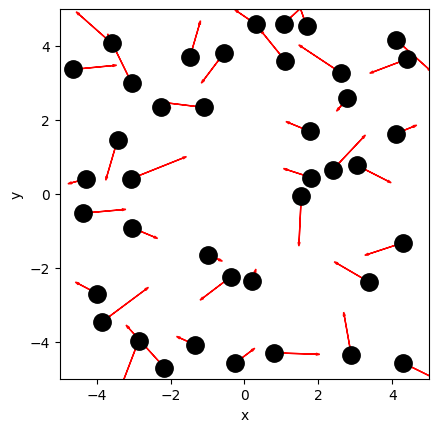

In [8]:
particles = []
create_particles(particles)
for i in range(100):
    take_time_step(particles)

plt.figure()
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.xlim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
plt.ylim(-BOX_SIZE_0/2, BOX_SIZE_0/2)

for p in particles:
    plt.plot(p.r[0], p.r[1], 'k.', ms=25)
    plt.arrow(p.r[0], p.r[1], p.v[0], p.v[1], 
              head_width=0.05, head_length=0.1, color='red')
plt.show()

Nu implementeren we de zuiger door het toegestane gebied voor de gasdeeltjes bij elke tijdstap te verkleinen met een stap $v_{\text{piston}}*dt$.

In [9]:
def take_time_step(particles):
    """ zet tijdstap voor een lijst deeltjes en verwerk alle botsingen onderling en met wanden """
    global box_length, v_piston
    box_length += 2 * v_piston * DT # zowel links als rechts zuiger
    for p in particles:
        p.update_position()
    handle_walls(particles)  
    handle_collisions(particles)

Hiermee draaien we een kleine simulatie over 1000 tijdstappen die kijkt naar de temperatuur als functie van het (oppervlak van) het beheersvolume.

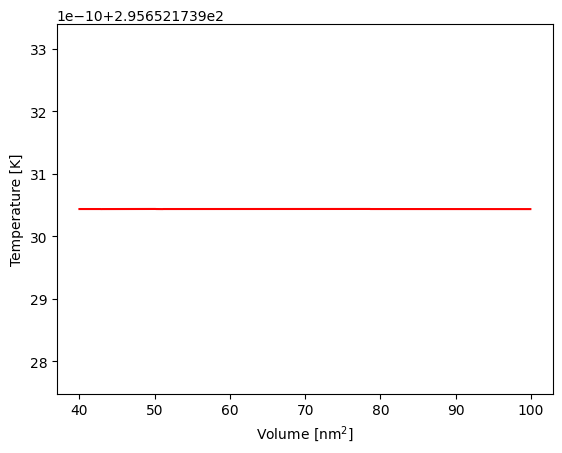

In [10]:
particles = []
volumes = np.zeros(1000, dtype=float)
temperatures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes     
for i in range(1000):
    take_time_step(particles)
    volumes[i] = box_length * box_height
    temperatures[i] = temperature(particles)

plt.figure()
plt.xlabel('Volume [nm$^2$]')
plt.ylabel('Temperature [K]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(volumes, temperatures, '-r')

plt.show()

Dit kan niet kloppen. Hier zien we dat de temperatuur vrijwel constant is (let op de vermenigvuldigingsfactor vermeld aan de bovenkant van de verticale as). Maar de zuiger voert arbeid uit en dat betekent dat de temperatuur moet veranderen vanwege de wet van behoud van energie. 

Om het model kloppend te maken moeten we kijken naar de botsing van de deeltjes met de wand. In de vorige werkbladen stonden de wanden stil en veranderde de snelheid van de deeltjes alleen van teken in de component loodrecht op de wand. Nu dat de wanden een zuiger zijn en snelheid hebben, moeten we daarvoor corrigeren.

De snelheid van de deeltjes klapt nog steeds om van teken in het referentiestelsel van de wand, maar omdat de wand beweegt ten opzichte van het volume met snelheid $v_{\text{piston}}$, wordt de juiste functie:

In [11]:
def left_right_collision(particle: ParticleClass):
    """ verzorgen van botsingen met wand links en rechts, die als zuiger kunnen bewegen """
    global box_length, v_piston, impulse_outward
    if abs(particle.r[0]) + particle.R > box_length / 2:
        particle.r[0] = np.sign(particle.r[0]) * (box_length/2 - particle.R)
        piston_velocity = np.sign(particle.r[0]) * v_piston
        relative_velocity = particle.v[0] - piston_velocity  # stelsel zuiger
        particle.v[0] = -relative_velocity + piston_velocity # stelsel waarnemer
        impulse_outward += 2 * particle.m * abs(relative_velocity) # stoot gevoeld door zuiger

Nu kunnen we de simulatie opnieuw uitvoeren:

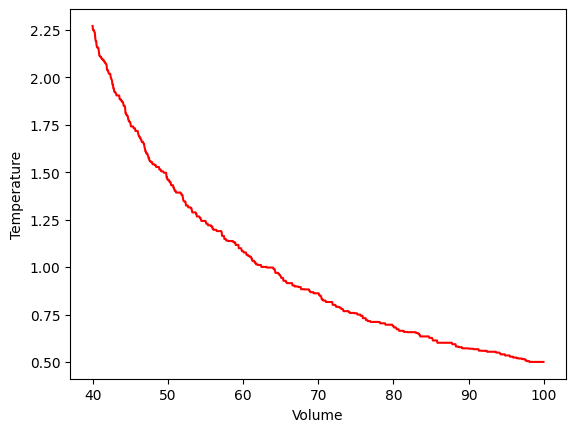

In [12]:
particles = []
volumes = np.zeros(1000, dtype=float)
temperatures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    volumes[i] = box_length * box_height
    temperatures[i] = temperature(particles)

plt.figure()
plt.xlabel('Volume')
plt.ylabel('Temperature')

temperatures = np.asarray(temperatures)

plt.plot(volumes, temperatures, '-r')

plt.show()

We zien nu een heel duidelijke afhankelijkheid van de temperatuur op het volume, zoals we ook verwachten vanwege de wet van behoud van energie. Natuurlijk willen we controleren of deze grafiek ook daadwerkelijk overeenkomt met onze verwachting, maar daarvoor is het waardevol om ook informatie te halen uit de andere grootheden. 

```{exercise}
Maak een simulatie waarin niet de temperatuur, maar de druk als functie van het volume wordt geplot. Gebruik dezelfde waarden voor het aantal tijdstappen en het volume, zoals in de startcode die je hieronder al ziet.
```

In [13]:
# breid deze code uit met jouw antwoord

particles = []
volumes = np.zeros(1000, dtype=float)
pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    # RUIMTE VOOR UITWERKING

# PLOT GRAFIEK

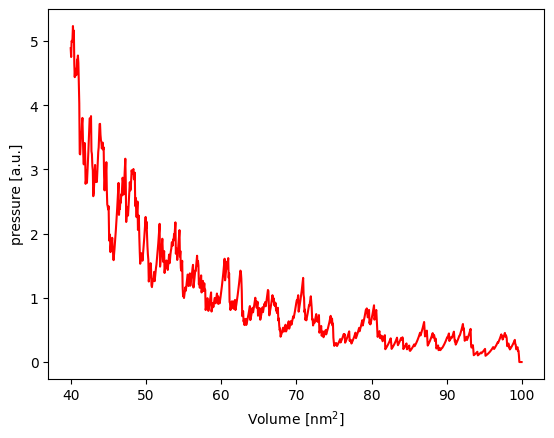

In [14]:
#VOORBEELDUITWERKING

particles = []
volumes = np.zeros(1000, dtype=float)
pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    volumes[i] = box_length * box_height
    pressures[i] = pressure

plt.figure()
plt.xlabel('Volume [nm$^2$]')
plt.ylabel('pressure [a.u.]')

plt.plot(volumes, pressures, '-r')

plt.show()

Als je simulatie klopt heeft deze grafiek de vorm van een machtsfunctie met een negatieve exponent. 

```{exercise}
:label: expected_exponent
Leg uit welke factor je hier verwacht voor de exponent op basis van de theorie van het boek.
```

```{solution} expected_exponent
Jouw antwoord hier...
```

```{exercise}
Bepaal met behulp van een fit wat het resultaat van de simulatie voor de machtsterm is.
```

In [15]:
def power_law(vol, a, n):
    """ de fitfunctie voor het P,V-diagram """
    return a * vol**n   

# RUIMTE VOOR VERDERE UITWERKING

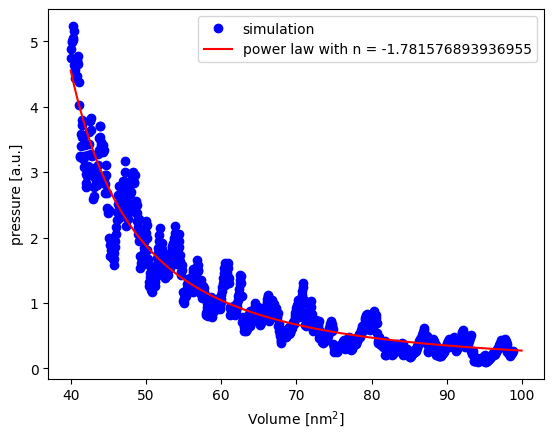

In [16]:
# VOORBEELDUITWERKING

def power_law(vol, a, b, n):
    return a * (vol - b)**n    

# we fitten de eerste 20 punten niet mee in verband met de integrator vd druk
popt, pocv = curve_fit(power_law, volumes[20:], pressures[20:], p0=[3000 ,20, -2])

x_fit = volumes
y_fit = power_law(x_fit, *popt)

plt.figure()
plt.xlabel('Volume [nm$^2$]')
plt.ylabel('pressure [a.u.]')

plt.plot(volumes[20:], pressures[20:], 'bo', label='simulation')
plt.plot(x_fit, y_fit, 'r-', label='power law with n = ' + str(popt[2]))

plt.legend()

plt.show()

Als je de simulatie een aantal keer uitvoert, zie je dat er een structureel verschil zit tussen de waarde die je verwacht en de waarde die je uit de fit krijgt.

```{exercise}
:label: reason_power
Wat is de belangrijkste reden voor deze afwijking? Geef een methode van aanpak waarmee je voor deze simulatie kan verifiëren of dit inderdaad de juiste is.
```

```{solution} reason_power
Jouw antwoord hier...
```

We gaan controleren of de simulatie voldoet aan de eerste hoofdwet van de thermodynamica. Omdat er (nog) geen warmte wordt uitgewisseld, moeten we hiervoor alleen de arbeid bepalen. De arbeid wordt geleverd door de zuiger(s) op de gasmoleculen. Dus op het moment dat we de botsingen van de moleculen met de wand behadelen, kunnen we ook de verrichte arbeid bepalen. Volgens het boek wordt die bepaalt door:

$$
    W = \int_1^2 P dV
$$

Hier staan de $1$ voor de begintoestand en de $2$ voor de eindtoestand van het proces. In de differentiaalvorm kan je dit herschrijven als:

$$
    \delta W = P dV
$$

Net als in het boek, kiezen we voor de notatie met $\delta W$ in plaats van $dW$, om aan te geven dat deze integraal afhankelijk is van het gekozen proces en niet alleen van het begin- en eindpunt. Voor ons experiment, waar het volume niet geleidelijk maar in stapjes verandert, kan je de hoeveelheid arbeid per tijdstip dus herschrijven tot:

$$ 
    \Delta W = P \Delta V \stackrel{2D}{=} P \Delta A = P v_{\text{piston}} h \Delta t = \frac{\Delta p}{h \Delta t} v_{\text{piston}} h \Delta t = v_{\text{piston}}\Delta p
$$

Dit betekent dat we de arbeid per tijdstap in onze code kunnen bepalen op hetzelfde moment dat we de druk bepalen met behulp van de gezamenlijke stoot van de moleculen. Daarvoor moeten we de code voor de functie `left_right_collision` nogmaals aanpassen:

In [17]:
def left_right_collision(particle: ParticleClass):
    """ verzorgen van botsingen met wand links en rechts, die als zuiger kunnen bewegen """
    global box_length, v_piston, impulse_outward, work
    if abs(particle.r[0]) + particle.R > box_length / 2:
        particle.r[0] = np.sign(particle.r[0]) * (box_length/2 - particle.R)
        piston_velocity = np.sign(particle.r[0]) * v_piston
        relative_velocity = particle.v[0] - piston_velocity  # stelsel zuiger
        particle.v[0] = -relative_velocity + piston_velocity # stelsel waarnemer
        impulse_outward += 2 * particle.m * abs(relative_velocity)
        work += 2 * particle.m * relative_velocity * piston_velocity

Voordat we een simulatie draaien is het goed even stil te staan en na te denken. Net als bij een experiment in het lab doorlopen we bewust de onderzoekscyclus. We moeten daarvoor eerst een hypothese opstellen en daarna pas de simulatie uitvoeren. 

```{exercise}
:label: keuze_grafiek
Welke twee grootheden kan je nu tegen elkaar uitzetten om te valideren of de simulatie aan de eerste hoofdwet voldoet? En welke grafiek verwacht je dan dat daar uitkomt?
```

```{solution} keuze_grafiek
Hier jouw antwoord...
```

```{exercise}
Stel de code op om deze grafiek te produceren. Neem wederom 1000 tijdstappen met de standaard snelheid voor de zuiger en vergelijk het resultaat met je hypothese.
```

In [18]:
temperatures = np.zeros(1000, dtype=float)
works = np.zeros(1000, dtype=float)

pressure = 0.0
work = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    # RUIMTE VOOR VERDERE UITWERKING

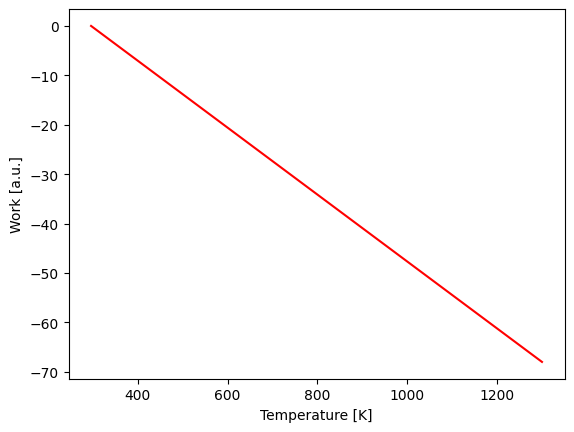

In [19]:
# VOORBEELDUITWERKING

particles = []
temperatures = np.zeros(1000, dtype=float)
works = np.zeros(1000, dtype=float)
# volumes = np.zeros(1000, dtype=float)
# pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
work = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work

plt.figure()
plt.xlabel('Temperature [K]')
plt.ylabel('Work [a.u.]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(temperatures, works, '-r')

plt.show()

Als laatste onderdeel van dit werkblad maken we een eenvoudige cyclus. We comprimeren het volume gedurende 1000 tijdstappen en keren daarna in 1000 gelijke tijdstappen terug naar het startvolume. 

```{exercise}
Herhaal voor deze simulatie de vorige plot. Gebruik een verschillende kleur voor de grafiek tijdens de compressie en de decompressie.
```

In [20]:
xvalues = np.zeros(2000, dtype=float) # 1000 heen en 1000 terug
yvalues = np.zeros(2000, dtype=float)

box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    # AANVULLEN UITWERKING
v_piston = -V_PISTON_0
for i in range(100,200):
    take_time_step(particles)
    # AANVULLEN UITWERKING

# AANVULLEN MET REST CODE

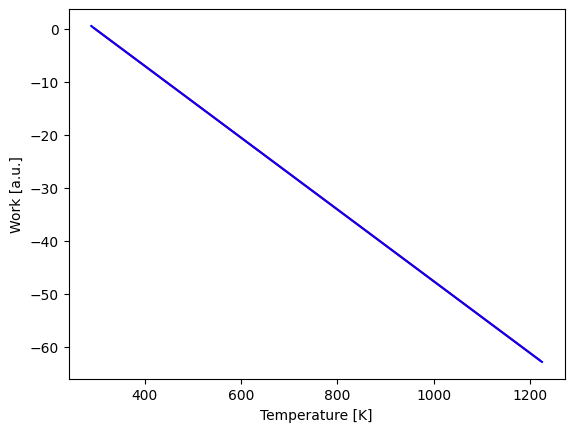

In [21]:
# VOORBEELDUITWERKING

particles = []
temperatures = np.zeros(2000, dtype=float)
works = np.zeros(2000, dtype=float)
# volumes = np.zeros(1000, dtype=float)
# pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
work = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work
v_piston = -V_PISTON_0
for i in range(1000,2000):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work

plt.figure()
plt.xlabel('Temperature [K]')
plt.ylabel('Work [a.u.]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(temperatures[0:999], works[0:999], '-r')
plt.plot(temperatures[1000:1999], works[1000:1999], '-b')

plt.show()

```{exercise}
Herhaal deze simulatie maar nu met een 5 keer zo hoge snelheid voor de zuiger in beide richtingen. Pas het aantal tijdstappen aan tot 400, zodat de zuiger in één 'slag' dezelfde afstand aflegt. 
```

In [22]:
# RUIMTE VOOR UITWERKING

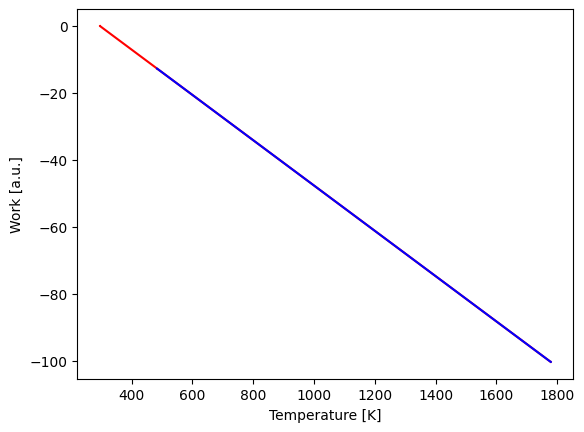

In [23]:
# VOORBEELDUITWERKING

particles = []
temperatures = np.zeros(400, dtype=float)
works = np.zeros(400, dtype=float)
# volumes = np.zeros(1000, dtype=float)
# pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
work = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = 5 * V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(200):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work
v_piston = -5 * V_PISTON_0
for i in range(200, 400):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work

plt.figure()
plt.xlabel('Temperature [K]')
plt.ylabel('Work [a.u.]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(temperatures[0:199], works[0:199], '-r')
plt.plot(temperatures[200:399], works[200:399], '-b')

plt.show()

In deze laatste simulatie zie je (bij een correcte code) dat nog altijd netjes wordt voldaan aan de eerste hoofdwet. Ondanks dat, zie je dat het systeem niet terugkeert in dezelfde toestand als in het begin. In het boek wordt dit omschreven in het deel over 'quasiequilibrium': Processen moeten voldoende traag plaatsvinden zodat er zich een evenwicht kan vormen binnen het gas. Als processen te snel plaatsvinden is er geen sprake van equilibrium en kan je de macroscopische thermodynamische formules niet langer gebruiken.

```{exercise}
Reken de snelheid van de zuiger bij de laatste twee processen om naar een snelheid in SI-eenheden, als je voor je code andere eenheden hebt gekozen. De kwaliteit van onze simulaties is onvoldoende gedetailleerd om echt uitspraken te kunnen doen over non-equilibrium processen. Maar het antwoord laat zien dat we ons in het laboratorium niet direct zorgen hoeven maken.
```

```{exercise}
Laat je werkboek aftekenen door een TA.
```